# REM Analysis for RAG Retrieval

This notebook analyzes retrieval performance with respect to the **Retrieval Efficiency Metric (REM)** for dense, sparse, and hybrid retrieval on the FIQA dataset.

It assumes you have already run the tuning script so that the following files exist under `../logs/`:

- `tuning_fiqa.csv` – per-query metrics for each retrieval type and run.
- `tuning_fiqa_runs.csv` – run-level aggregates (mean accuracy, mean REM, and hyperparameters).
- `tuning_fiqa_best.txt` – text summary of the best runs by accuracy and REM.

You can regenerate these by running, from the project root:

```bash
python scripts/run_tuning.py
```

The notebook will:

- Load tuning logs and inspect their schema.
- Compute aggregate metrics per retrieval type.
- Visualize how REM trades off accuracy, latency, and cost across hyperparameters.
- Save figures into `../figures/` for inclusion in the main report.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Paths
project_root = Path("..").resolve()
logs_dir = project_root / "logs"
figures_dir = project_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

combined_path = logs_dir / "tuning_fiqa.csv"
runs_path = logs_dir / "tuning_fiqa_runs.csv"


print(f"Project root: {project_root}")
print(f"Combined tuning logs: {combined_path}")
print(f"Run-level logs: {runs_path}")

# Load data if available
combined_df = None
runs_df = None

if combined_path.exists():
    combined_df = pd.read_csv(combined_path)
    # Quick look at accuracy, MAP@k, and nDCG@k for the first few rows
    combined_df[["run_id", "retrieval_type", "accuracy", "map_at_k", "ndcg_at_k"]].head(10)
    display(combined_df.head())
else:
    print("[WARN] Combined tuning file not found. Run 'python scripts/run_tuning.py' first.")

if runs_path.exists():
    runs_df = pd.read_csv(runs_path)
    display(runs_df.head())
else:
    print("[WARN] Run-level tuning file not found. Run 'python scripts/run_tuning.py' first.")
# Quick look at accuracy, MAP@k, and nDCG@k for the first few rows

Project root: /Users/cletu/projects/RAG
Combined tuning logs: /Users/cletu/projects/RAG/logs/tuning_fiqa.csv
Run-level logs: /Users/cletu/projects/RAG/logs/tuning_fiqa_runs.csv


,query_id,query,retrieval_type,accuracy,map_at_k,ndcg_at_k,recall_at_k,latency_s,cost_tokens,accuracy_norm,latency_norm,cost_norm,REM,run_id,top_k,w_dense,w_sparse,accuracy_at_k
0,4641,Where should I park my rainy-day / emergency f...,dense,1.0,0.2,0.339160,0.2,2.801881,465.0,1.0,1.000000,0.000000,0.700000,1,5,0.5,0.5,5
1,4641,Where should I park my rainy-day / emergency f...,sparse,0.0,0.0,0.000000,0.0,0.145458,1264.0,0.0,0.000000,1.000000,0.300000,1,5,0.5,0.5,5
2,4641,Where should I park my rainy-day / emergency f...,hybrid,1.0,0.1,0.213986,0.2,0.160367,702.0,1.0,0.005612,0.296621,0.938992,1,5,0.5,0.5,5
3,5503,Tax considerations for selling a property belo...,dense,0.0,0.0,0.000000,0.0,0.050953,774.0,1.0,0.000000,0.000000,1.000000,1,5,0.5,0.5,5
4,5503,Tax considerations for selling a property belo...,sparse,0.0,0.0,0.000000,0.0,0.179287,1141.0,1.0,1.000000,1.000000,0.500000,1,5,0.5,0.5,5


,run_id,mean_accuracy,mean_REM,top_k,w_dense,w_sparse,accuracy_at_k
0,1,0.415123,0.659943,5,0.5,0.5,5
1,2,0.415123,0.661925,5,0.5,0.5,10
2,3,0.415123,0.661570,5,0.5,0.5,20
3,4,0.416667,0.665488,5,0.6,0.4,5
4,5,0.416667,0.665964,5,0.6,0.4,10


In [2]:
# Basic aggregates: per-retrieval-type means over a chosen run

if combined_df is not None:
    if "run_id" in combined_df.columns:
        # Default to best-by-REM run if runs_df is available, else max run_id
        run_id = None
        if runs_df is not None and "mean_REM" in runs_df.columns:
            best_row = runs_df.loc[runs_df["mean_REM"].idxmax()]
            run_id = int(best_row["run_id"])
            print(f"Using best-by-REM run_id={run_id} for per-type aggregates.")
        else:
            run_id = int(combined_df["run_id"].max())
            print(f"Using last run_id={run_id} for per-type aggregates.")

        run_slice = combined_df[combined_df["run_id"] == run_id]
    else:
        run_slice = combined_df
        print("No run_id column; using all rows.")

    per_type = run_slice.groupby("retrieval_type")[
        ["accuracy", "latency_s", "cost_tokens", "REM"]
    ].mean().round(4)
    display(per_type)
else:
    print("No combined_df loaded; skip aggregates.")


Using best-by-REM run_id=26 for per-type aggregates.


,accuracy,latency_s,cost_tokens,REM
retrieval_type,,,,
dense,0.5139,0.0320,2222.8642,0.9240
hybrid,0.5741,0.1833,2842.2623,0.6018
sparse,0.4182,0.1457,4125.2824,0.4903


Best-by-REM run_id=26


,accuracy,latency_s,cost_tokens,REM
retrieval_type,,,,
dense,0.5139,0.0320,2222.8642,0.9240
hybrid,0.5741,0.1833,2842.2623,0.6018
sparse,0.4182,0.1457,4125.2824,0.4903


Saved bar metrics figure to /Users/cletu/projects/RAG/figures/rem_best_run_metrics.png


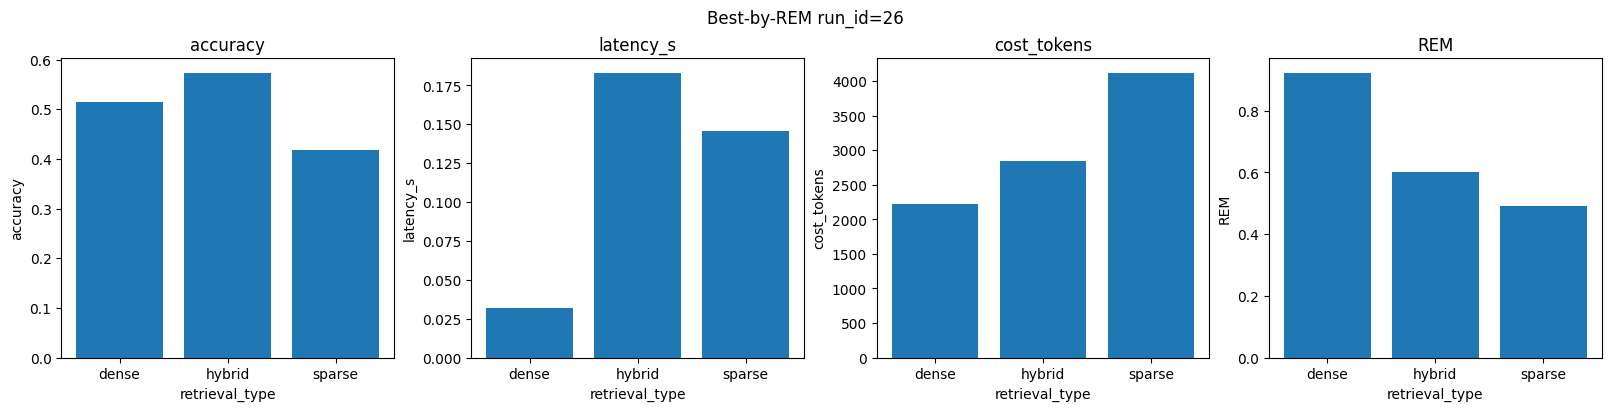

Saved scatter figure to /Users/cletu/projects/RAG/figures/rem_accuracy_vs_rem_scatter.png


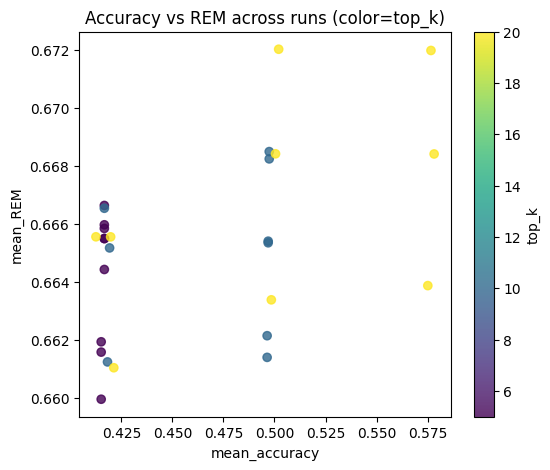

Saved heatmap figure to /Users/cletu/projects/RAG/figures/rem_heatmap_topk_wdense.png


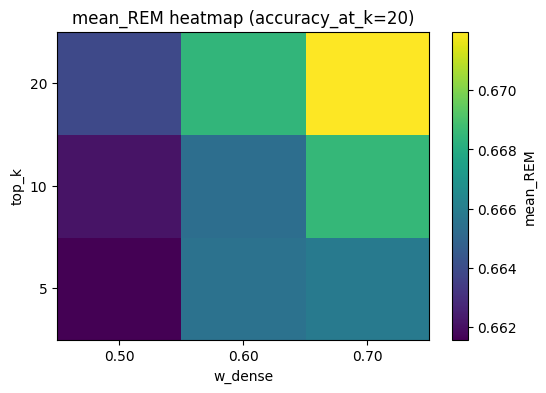

Saved REM distribution figure to /Users/cletu/projects/RAG/figures/rem_distribution_hist.png


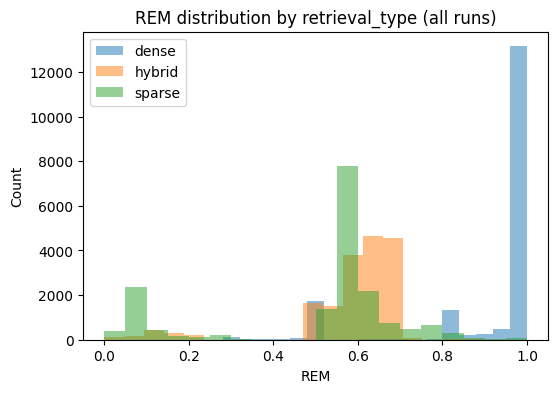

In [3]:
"""Plots relating performance to REM.

This cell generates:
- Bar charts of accuracy, latency, cost, and REM for the best-by-REM run.
- A scatter plot of mean_accuracy vs mean_REM across runs (color-coded by top_k).
- A heatmap of mean_REM over (top_k, w_dense) for a fixed accuracy_at_k.
- A histogram of REM distributions per retrieval_type across all runs.
"""

if combined_df is None or runs_df is None:
    print("Tuning logs not fully available; skipping plots.")
else:
    # Best-by-REM run
    best_row = runs_df.loc[runs_df["mean_REM"].idxmax()]
    best_run_id = int(best_row["run_id"])
    print(f"Best-by-REM run_id={best_run_id}")

    best_slice = combined_df[combined_df["run_id"] == best_run_id]
    per_type_best = best_slice.groupby("retrieval_type")[
        ["accuracy", "latency_s", "cost_tokens", "REM"]
    ].mean().round(4)
    display(per_type_best)

    # Bar plots for best-by-REM run
    metrics = ["accuracy", "latency_s", "cost_tokens", "REM"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), constrained_layout=True)

    for ax, metric in zip(axes, metrics):
        ax.bar(per_type_best.index, per_type_best[metric])
        ax.set_title(metric)
        ax.set_ylabel(metric)
        ax.set_xlabel("retrieval_type")

    fig.suptitle(f"Best-by-REM run_id={best_run_id}")
    bar_path = figures_dir / "rem_best_run_metrics.png"
    fig.savefig(bar_path, dpi=200, bbox_inches="tight")
    print(f"Saved bar metrics figure to {bar_path}")
    plt.show()

    # Scatter: mean_accuracy vs mean_REM across runs
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(
        runs_df["mean_accuracy"],
        runs_df["mean_REM"],
        c=runs_df["top_k"],
        cmap="viridis",
        alpha=0.8,
    )
    ax.set_xlabel("mean_accuracy")
    ax.set_ylabel("mean_REM")
    ax.set_title("Accuracy vs REM across runs (color=top_k)")
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("top_k")
    scatter_path = figures_dir / "rem_accuracy_vs_rem_scatter.png"
    fig.savefig(scatter_path, dpi=200, bbox_inches="tight")
    print(f"Saved scatter figure to {scatter_path}")
    plt.show()

    # Heatmap: mean_REM over (top_k, w_dense) for a fixed accuracy_at_k
    if "accuracy_at_k" in runs_df.columns and "w_dense" in runs_df.columns:
        # Use the largest accuracy_at_k as a representative setting
        k_values = sorted(runs_df["accuracy_at_k"].unique())
        k0 = k_values[-1]
        subset = runs_df[runs_df["accuracy_at_k"] == k0]
        pivot = subset.pivot(index="top_k", columns="w_dense", values="mean_REM")

        fig, ax = plt.subplots(figsize=(6, 4))
        im = ax.imshow(pivot.values, origin="lower", aspect="auto", cmap="viridis")

        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([f"{c:.2f}" for c in pivot.columns])
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("w_dense")
        ax.set_ylabel("top_k")
        ax.set_title(f"mean_REM heatmap (accuracy_at_k={k0})")

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("mean_REM")

        heatmap_path = figures_dir / "rem_heatmap_topk_wdense.png"
        fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
        print(f"Saved heatmap figure to {heatmap_path}")
        plt.show()
    else:
        print("Skipping heatmap: missing columns 'accuracy_at_k' or 'w_dense' in runs_df.")

    # REM distribution per retrieval_type across all runs
    fig, ax = plt.subplots(figsize=(6, 4))
    for rtype in sorted(combined_df["retrieval_type"].unique()):
        vals = combined_df.loc[combined_df["retrieval_type"] == rtype, "REM"]
        ax.hist(vals, bins=20, alpha=0.5, label=rtype)

    ax.set_xlabel("REM")
    ax.set_ylabel("Count")
    ax.set_title("REM distribution by retrieval_type (all runs)")
    ax.legend()
    dist_path = figures_dir / "rem_distribution_hist.png"
    fig.savefig(dist_path, dpi=200, bbox_inches="tight")
    print(f"Saved REM distribution figure to {dist_path}")
    plt.show()


Best-by-REM run_id=26 for radar plot.
Saved radar figure to /Users/cletu/projects/RAG/figures/rem_radar_metrics.png


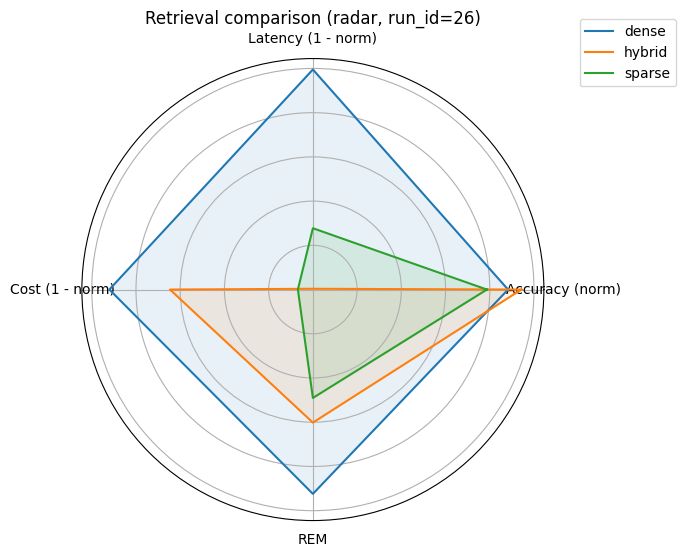

In [4]:
# Radar plot of normalized metrics for best-by-REM run

if combined_df is None or runs_df is None:
    print("Tuning logs not fully available; skipping radar plot.")
else:
    # Select best-by-REM run
    best_row = runs_df.loc[runs_df["mean_REM"].idxmax()]
    best_run_id = int(best_row["run_id"])
    print(f"Best-by-REM run_id={best_run_id} for radar plot.")

    subset = combined_df[combined_df["run_id"] == best_run_id]

    # Aggregate normalized metrics by retrieval_type
    required_cols = {"accuracy_norm", "latency_norm", "cost_norm", "REM"}
    if not required_cols.issubset(subset.columns):
        missing = required_cols - set(subset.columns)
        print(f"Missing required columns for radar plot: {missing}")
    else:
        grouped = subset.groupby("retrieval_type")[
            ["accuracy_norm", "latency_norm", "cost_norm", "REM"]
        ].mean().copy()

        grouped["latency_eff"] = 1.0 - grouped["latency_norm"]
        grouped["cost_eff"] = 1.0 - grouped["cost_norm"]

        metrics = ["accuracy_norm", "latency_eff", "cost_eff", "REM"]
        labels = ["Accuracy (norm)", "Latency (1 - norm)", "Cost (1 - norm)", "REM"]

        num_vars = len(metrics)
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        angles += angles[:1]

        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

        for name, row in grouped.iterrows():
            values = [row[m] for m in metrics]
            values += values[:1]
            ax.plot(angles, values, label=name)
            ax.fill(angles, values, alpha=0.1)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels)
        ax.set_yticklabels([])
        ax.set_title(f"Retrieval comparison (radar, run_id={best_run_id})")
        ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

        radar_path = figures_dir / "rem_radar_metrics.png"
        fig.savefig(radar_path, dpi=200, bbox_inches="tight")
        print(f"Saved radar figure to {radar_path}")
        plt.show()

In [5]:
# Paired t-tests between retrieval methods on MAP@k and nDCG@k (best-by-REM run)

from scipy.stats import ttest_rel
import numpy as np

if combined_df is None or runs_df is None:
    print("No tuning logs loaded; run the setup cell first.")
else:
    best_row = runs_df.loc[runs_df["mean_REM"].idxmax()]
    best_run_id = int(best_row["run_id"])
    print(f"Running paired t-tests for run_id={best_run_id}.")

    subset = combined_df[combined_df["run_id"] == best_run_id]

    def metric_vector(metric: str, rtype: str) -> np.ndarray:
        return subset[subset["retrieval_type"] == rtype][metric].to_numpy()

    results = []
    for metric in ["map_at_k", "ndcg_at_k"]:
        dense_vals = metric_vector(metric, "dense")
        sparse_vals = metric_vector(metric, "sparse")
        hybrid_vals = metric_vector(metric, "hybrid")

        # dense vs sparse
        t_ds, p_ds = ttest_rel(dense_vals, sparse_vals)
        # dense vs hybrid
        t_dh, p_dh = ttest_rel(dense_vals, hybrid_vals)
        # sparse vs hybrid
        t_sh, p_sh = ttest_rel(sparse_vals, hybrid_vals)

        results.append(
            {
                "metric": metric,
                "t_dense_sparse": t_ds,
                "p_dense_sparse": p_ds,
                "t_dense_hybrid": t_dh,
                "p_dense_hybrid": p_dh,
                "t_sparse_hybrid": t_sh,
                "p_sparse_hybrid": p_sh,
            }
        )

    import pandas as _pd

    ttest_df = _pd.DataFrame(results)
    display(ttest_df)

Running paired t-tests for run_id=26.


,metric,t_dense_sparse,p_dense_sparse,t_dense_hybrid,p_dense_hybrid,t_sparse_hybrid,p_sparse_hybrid
0,map_at_k,4.175177,0.000034,-6.100526,1.819901e-09,-6.693054,4.741813e-11
1,ndcg_at_k,4.735258,0.000003,-7.152768,2.308990e-12,-7.991360,6.138779e-15


Saved Pareto frontier figure to /Users/cletu/projects/RAG/figures/rem_pareto_accuracy_latency_fiqa.png


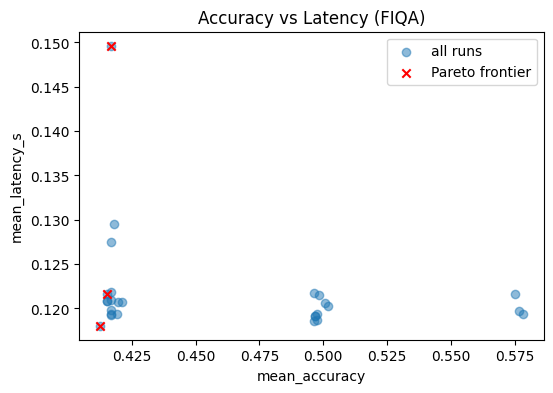

Saved top_k accuracy figure to /Users/cletu/projects/RAG/figures/rem_topk_sensitivity_accuracy_fiqa.png


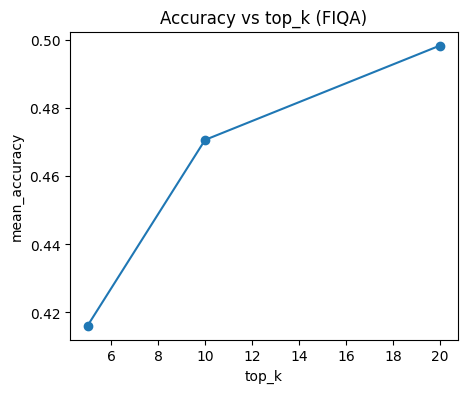

Saved top_k REM figure to /Users/cletu/projects/RAG/figures/rem_topk_sensitivity_rem_fiqa.png


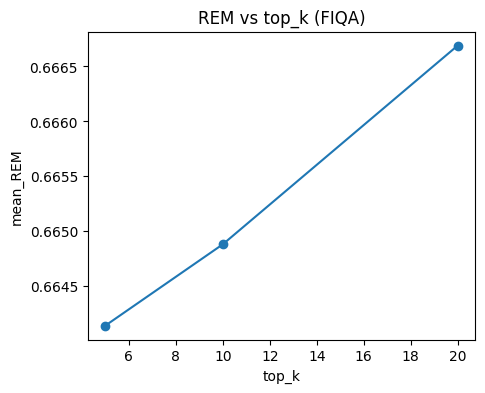

In [6]:
# Pareto frontier and top_k sensitivity for FIQA

import numpy as np
import matplotlib.pyplot as plt

if combined_df is None or runs_df is None:
    print("No tuning logs loaded; run the setup cell first.")
else:
    # Derive mean latency per run from combined_df
    agg_lat = combined_df.groupby("run_id")["latency_s"].mean().reset_index()
    runs = runs_df.merge(agg_lat, on="run_id", how="left").rename(
        columns={"latency_s": "mean_latency_s"}
    )

    def pareto_frontier(df):
        pts = df[["mean_accuracy", "mean_latency_s"]].to_numpy()
        is_pareto = np.ones(pts.shape[0], dtype=bool)
        for i, p in enumerate(pts):
            if not is_pareto[i]:
                continue
            dominates = (pts[:, 0] >= p[0]) & (pts[:, 1] <= p[1]) & (
                (pts[:, 0] > p[0]) | (pts[:, 1] < p[1])
            )
            is_pareto[dominates] = False
        return df[is_pareto]

    frontier = pareto_frontier(runs)

    # Accuracy vs latency with Pareto frontier
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(runs["mean_accuracy"], runs["mean_latency_s"], alpha=0.5, label="all runs")
    ax.scatter(
        frontier["mean_accuracy"],
        frontier["mean_latency_s"],
        color="red",
        marker="x",
        label="Pareto frontier",
    )
    ax.set_xlabel("mean_accuracy")
    ax.set_ylabel("mean_latency_s")
    ax.set_title("Accuracy vs Latency (FIQA)")
    ax.legend()

    pareto_path = figures_dir / "rem_pareto_accuracy_latency_fiqa.png"
    fig.savefig(pareto_path, dpi=200, bbox_inches="tight")
    print(f"Saved Pareto frontier figure to {pareto_path}")
    plt.show()

    # top_k sensitivity (averaged over other params)
    acc_by_topk = runs.groupby("top_k")["mean_accuracy"].mean().reset_index()
    rem_by_topk = runs.groupby("top_k")["mean_REM"].mean().reset_index()

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(acc_by_topk["top_k"], acc_by_topk["mean_accuracy"], marker="o")
    ax.set_xlabel("top_k")
    ax.set_ylabel("mean_accuracy")
    ax.set_title("Accuracy vs top_k (FIQA)")
    topk_acc_path = figures_dir / "rem_topk_sensitivity_accuracy_fiqa.png"
    fig.savefig(topk_acc_path, dpi=200, bbox_inches="tight")
    print(f"Saved top_k accuracy figure to {topk_acc_path}")
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot(rem_by_topk["top_k"], rem_by_topk["mean_REM"], marker="o")
    ax.set_xlabel("top_k")
    ax.set_ylabel("mean_REM")
    ax.set_title("REM vs top_k (FIQA)")
    topk_rem_path = figures_dir / "rem_topk_sensitivity_rem_fiqa.png"
    fig.savefig(topk_rem_path, dpi=200, bbox_inches="tight")
    print(f"Saved top_k REM figure to {topk_rem_path}")
    plt.show()

In [7]:
# Retrieval error analysis: sample failed hybrid queries (accuracy@k = 0)

if combined_df is None or runs_df is None:
    print("No tuning logs loaded; run the setup cell first.")
else:
    # Use best-by-REM run for error analysis
    best_row = runs_df.loc[runs_df["mean_REM"].idxmax()]
    best_run_id = int(best_row["run_id"])
    subset = combined_df[combined_df["run_id"] == best_run_id]

    failures = subset[(subset["retrieval_type"] == "hybrid") & (subset["accuracy"] == 0.0)]
    print(f"Found {len(failures)} hybrid failures (accuracy@k = 0) in run_id={best_run_id}.")

    # Sample a small number for manual inspection
    sample_failures = failures.sample(min(10, len(failures)), random_state=0) if len(failures) > 0 else failures
    display(sample_failures[["query_id", "query", "accuracy", "map_at_k", "ndcg_at_k", "cost_tokens"]])

    # For a given failed query_id, you can look up the dense/sparse/hybrid rows
    # and inspect their retrieved texts by joining back to the original logs or
    # by adding extra logging in the runner if you want full text here.

Found 276 hybrid failures (accuracy@k = 0) in run_id=26.


,query_id,query,accuracy,map_at_k,ndcg_at_k,cost_tokens
49907,4499,Is investing exlusively in a small-cap index f...,0.0,0.0,0.0,3351.0
48713,2108,Can I pay taxes using bill pay from my on-line...,0.0,0.0,0.0,2576.0
48959,5402,Is it impossible to get a home loan with a poo...,0.0,0.0,0.0,3628.0
49097,5090,Should I take a student loan to pursue my unde...,0.0,0.0,0.0,3564.0
49928,9108,"Starting an investment portfolio with Rs 5,000/-",0.0,0.0,0.0,4174.0
50069,5534,How does “taking over payments” work?,0.0,0.0,0.0,1029.0
49190,9403,Abundance of Cash - What should I do?,0.0,0.0,0.0,1438.0
50144,5061,What fiscal scrutiny can be expected from IRS ...,0.0,0.0,0.0,2670.0
49475,7295,Selling non-dividend for dividend stocks,0.0,0.0,0.0,1729.0
49943,3067,Should I make extra payments to my under water...,0.0,0.0,0.0,3195.0


In [8]:
# Per-retrieval-type summary of accuracy, MAP@k, and nDCG@k for best-by-REM run

if combined_df is None or runs_df is None:
    print("No tuning logs loaded; run the setup cell and make sure tuning has been run.")
else:
    best_row = runs_df.loc[runs_df["mean_REM"].idxmax()]
    best_run_id = int(best_row["run_id"])
    print(f"Summarizing rank metrics for best-by-REM run_id={best_run_id}.")

    subset = combined_df[combined_df["run_id"] == best_run_id]

    rank_summary = subset.groupby("retrieval_type")[
        ["accuracy", "map_at_k", "ndcg_at_k", "REM"]
    ].mean().round(4)
    display(rank_summary)

Summarizing rank metrics for best-by-REM run_id=26.


,accuracy,map_at_k,ndcg_at_k,REM
retrieval_type,,,,
dense,0.5139,0.2029,0.2680,0.9240
hybrid,0.5741,0.2263,0.2975,0.6018
sparse,0.4182,0.1494,0.2016,0.4903


Saved rank metrics figure to /Users/cletu/projects/RAG/figures/rem_rank_metrics_best_run.png


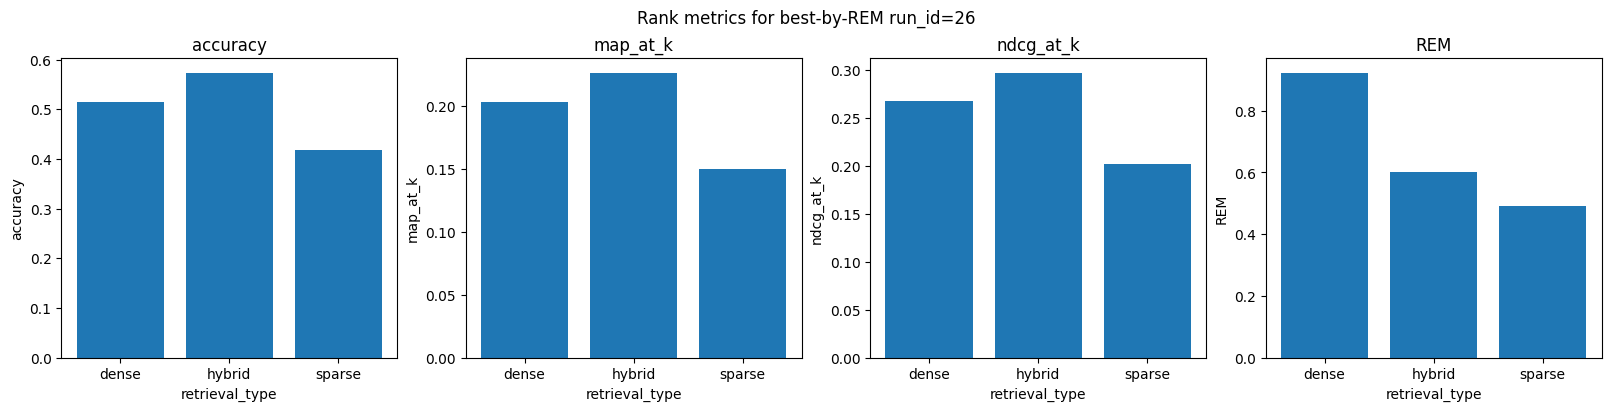

In [9]:
# Bar plots for accuracy, MAP@k, nDCG@k, and REM (best-by-REM run)

if combined_df is None or runs_df is None:
    print("No tuning logs loaded; run the setup cell and make sure tuning has been run.")
else:
    best_row = runs_df.loc[runs_df["mean_REM"].idxmax()]
    best_run_id = int(best_row["run_id"])
    subset = combined_df[combined_df["run_id"] == best_run_id]

    rank_summary = subset.groupby("retrieval_type")[
        ["accuracy", "map_at_k", "ndcg_at_k", "REM"]
    ].mean().round(4)

    metrics = ["accuracy", "map_at_k", "ndcg_at_k", "REM"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), constrained_layout=True)

    for ax, metric in zip(axes, metrics):
        ax.bar(rank_summary.index, rank_summary[metric])
        ax.set_title(metric)
        ax.set_ylabel(metric)
        ax.set_xlabel("retrieval_type")

    fig.suptitle(f"Rank metrics for best-by-REM run_id={best_run_id}")
    rank_fig_path = figures_dir / "rem_rank_metrics_best_run.png"
    fig.savefig(rank_fig_path, dpi=200, bbox_inches="tight")
    print(f"Saved rank metrics figure to {rank_fig_path}")
    plt.show()